In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import exp
from mpl_toolkits.mplot3d import Axes3D

# Datensatz laden
df = pd.read_csv("orings.csv")
display(df.head())

print("Spaltennamen:", df.columns.tolist())

,mission,temperature,damaged,undamaged
0,1,53,5,1
1,2,57,1,5
2,3,58,1,5
3,4,63,1,5
4,5,66,0,6


Spaltennamen: ['mission', 'temperature', 'damaged', 'undamaged']


In [19]:
# Temperatur und beschädigte O-Ringe aus CSV
temp = df["temperature"].values.astype(float)
damaged = df["damaged"].values.astype(int)

# Binäre Zielvariable:
# 1 = mindestens ein O-Ring beschädigt
# 0 = kein O-Ring beschädigt
y = (damaged > 0).astype(float)

print("Anzahl Beobachtungen:", len(temp))
print("Temperaturen:", temp)
print("Beschädigte O-Ringe:", damaged)
print("Binäre Zielvariable y:", y)

Anzahl Beobachtungen: 23
Temperaturen: [53. 57. 58. 63. 66. 67. 67. 67. 68. 69. 70. 70. 70. 70. 72. 73. 75. 75.
 76. 76. 78. 79. 81.]
Beschädigte O-Ringe: [5 1 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0]
Binäre Zielvariable y: [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [20]:
# Unstandardisierte Daten
X_unstd = np.column_stack([np.ones(len(temp)), temp])

# Standardisierte Daten
mu = temp.mean()
sigma_x = temp.std()
x_std = (temp - mu) / sigma_x
X_std = np.column_stack([np.ones(len(x_std)), x_std])

print("Mittelwert mu =", mu)
print("Standardabweichung sigma_x =", sigma_x)

Mittelwert mu = 69.56521739130434
Standardabweichung sigma_x = 6.901959941907628


In [21]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def loss(theta, X, y):
    p = sigmoid(X @ theta)
    eps = 1e-12
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

def gradient(theta, X, y):
    p = sigmoid(X @ theta)
    return (X.T @ (p - y)) / len(y)

def gradient_descent(X, y, lr=0.1, max_iter=50000, tol=1e-12):
    theta = np.zeros(X.shape[1])
    history = []

    for i in range(max_iter):
        grad = gradient(theta, X, y)
        theta_new = theta - lr * grad
        history.append(loss(theta_new, X, y))

        if np.linalg.norm(theta_new - theta, ord=2) < tol:
            theta = theta_new
            break

        theta = theta_new

    return theta, np.array(history)

def gradient_descent_with_path(X, y, lr=0.1, max_iter=50):
    theta = np.zeros(X.shape[1])
    path = [theta.copy()]

    for i in range(max_iter):
        grad = gradient(theta, X, y)
        theta = theta - lr * grad
        path.append(theta.copy())

    return np.array(path)

def predict_proba_unstd(temp_values, theta0, theta1):
    z = theta0 + theta1 * temp_values
    return sigmoid(z)

def predict_proba_std(temp_values, theta0_std, theta1_std, mu, sigma_x):
    x_values_std = (temp_values - mu) / sigma_x
    z = theta0_std + theta1_std * x_values_std
    return sigmoid(z)

In [24]:
theta_unstd, history_unstd = gradient_descent(
    X_unstd, y, lr=0.001, max_iter=50000, tol=1e-12
)

theta0, theta1 = theta_unstd
final_loss_unstd = loss(theta_unstd, X_unstd, y)

print("Unstandardisiertes Modell")
print("-------------------------")
print(f"theta0 = {theta0:.6f}")
print(f"theta1 = {theta1:.6f}")
print(f"final loss = {final_loss_unstd:.6f}")
print(f"Iterationen = {len(history_unstd)}")

Unstandardisiertes Modell
-------------------------
theta0 = 1.126359
theta1 = -0.029685
final loss = 0.567260
Iterationen = 50000


In [ ]:
#Modell auf standardisierten Daten trainieren

In [25]:
theta_std, history_std = gradient_descent(
    X_std, y, lr=0.1, max_iter=50000, tol=1e-12
)

theta0_std, theta1_std = theta_std
final_loss_std = loss(theta_std, X_std, y)

print("Standardisiertes Modell")
print("-----------------------")
print(f"theta0* = {theta0_std:.6f}")
print(f"theta1* = {theta1_std:.6f}")
print(f"final loss = {final_loss_std:.6f}")
print(f"Iterationen = {len(history_std)}")

Standardisiertes Modell
-----------------------
theta0* = -1.107550
theta1* = -1.602378
final loss = 0.441635
Iterationen = 3193


In [ ]:
#Standardisierte Parameter auf Originalskala zurückrechnen

In [26]:
# Theta auspacken (WICHTIG!)
theta0_std, theta1_std = theta_std

# Rücktransformation
theta1_from_std = theta1_std / sigma_x
theta0_from_std = theta0_std - (theta1_std * mu / sigma_x)

print("Rücktransformierte Parameter des standardisierten Modells")
print("---------------------------------------------------------")
print(f"theta0 = {theta0_from_std:.6f}")
print(f"theta1 = {theta1_from_std:.6f}")

Rücktransformierte Parameter des standardisierten Modells
---------------------------------------------------------
theta0 = 15.042902
theta1 = -0.232163


In [ ]:
#Inhaltliche Interpretation

In [27]:
print("Interpretation der Parameter")
print("----------------------------")
print(f"theta0 = {theta0:.6f}: Log-Odds eines O-Ring-Ausfalls bei T = 0°F")
print(f"theta1 = {theta1:.6f}: Änderung der Log-Odds pro zusätzlichem 1°F")

print("\nOdds Ratio pro 1°F:")
print(np.exp(theta1))

print("\nInterpretation standardisierte Parameter")
print("----------------------------------------")
print(f"theta0* = {theta0_std:.6f}: Log-Odds bei Durchschnittstemperatur T = {mu:.2f}°F")
print(f"theta1* = {theta1_std:.6f}: Änderung der Log-Odds pro 1 Standardabweichung der Temperatur")

Interpretation der Parameter
----------------------------
theta0 = 1.126359: Log-Odds eines O-Ring-Ausfalls bei T = 0°F
theta1 = -0.029685: Änderung der Log-Odds pro zusätzlichem 1°F

Odds Ratio pro 1°F:
0.9707509814643808

Interpretation standardisierte Parameter
----------------------------------------
theta0* = -1.107550: Log-Odds bei Durchschnittstemperatur T = 69.57°F
theta1* = -1.602378: Änderung der Log-Odds pro 1 Standardabweichung der Temperatur


In [ ]:
#50%-Temperatur und Vergleich mit Challenger-Start

In [28]:
t_50 = -theta0 / theta1
print(f"Temperatur bei 50% Ausfallwahrscheinlichkeit: {t_50:.2f}°F")

challenger_temp = 31
p_31 = predict_proba_unstd(np.array([challenger_temp]), theta0, theta1)[0]

print(f"Tatsächliche Starttemperatur Challenger: {challenger_temp}°F")
print(f"Geschätzte Ausfallwahrscheinlichkeit bei 31°F: {p_31:.6f}")

Temperatur bei 50% Ausfallwahrscheinlichkeit: 37.94°F
Tatsächliche Starttemperatur Challenger: 31°F
Geschätzte Ausfallwahrscheinlichkeit bei 31°F: 0.551347


In [ ]:
#Loss-Verlauf vergleichen

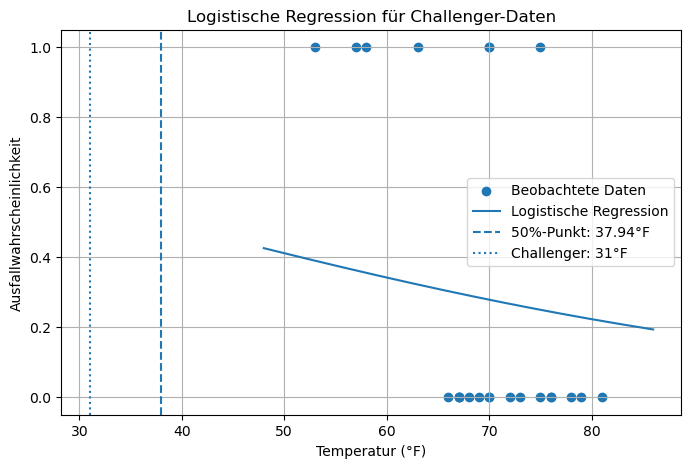

In [29]:
temp_grid = np.linspace(temp.min() - 5, temp.max() + 5, 300)
prob_grid = predict_proba_unstd(temp_grid, theta0, theta1)

plt.figure(figsize=(8, 5))
plt.scatter(temp, y, label="Beobachtete Daten")
plt.plot(temp_grid, prob_grid, label="Logistische Regression")
plt.axvline(t_50, linestyle="--", label=f"50%-Punkt: {t_50:.2f}°F")
plt.axvline(31, linestyle=":", label="Challenger: 31°F")
plt.xlabel("Temperatur (°F)")
plt.ylabel("Ausfallwahrscheinlichkeit")
plt.title("Logistische Regression für Challenger-Daten")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Loss-Verlauf vergleichen

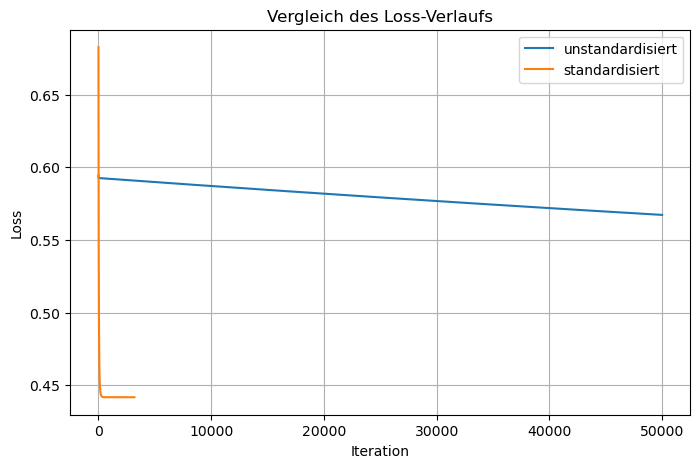

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(history_unstd, label="unstandardisiert")
plt.plot(history_std, label="standardisiert")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Vergleich des Loss-Verlaufs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Lossoberfläche standardisiert

In [39]:
# --- unstandardisierte Lossoberfläche ---
theta0_vals = np.linspace(theta0 - 10, theta0 + 10, 80)
theta1_vals = np.linspace(theta1 - 0.3, theta1 + 0.3, 80)

T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
Z_unstd = np.zeros_like(T0)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        theta_test = np.array([T0[i, j], T1[i, j]])
        Z_unstd[i, j] = loss(theta_test, X_unstd, y)

# --- standardisierte Lossoberfläche ---
theta0s_vals = np.linspace(theta0_std - 5, theta0_std + 5, 80)
theta1s_vals = np.linspace(theta1_std - 5, theta1_std + 5, 80)

T0s, T1s = np.meshgrid(theta0s_vals, theta1s_vals)
Z_std = np.zeros_like(T0s)

for i in range(T0s.shape[0]):
    for j in range(T0s.shape[1]):
        theta_test = np.array([T0s[i, j], T1s[i, j]])
        Z_std[i, j] = loss(theta_test, X_std, y)

In [ ]:
#Contour-Plots der Lossoberflächen

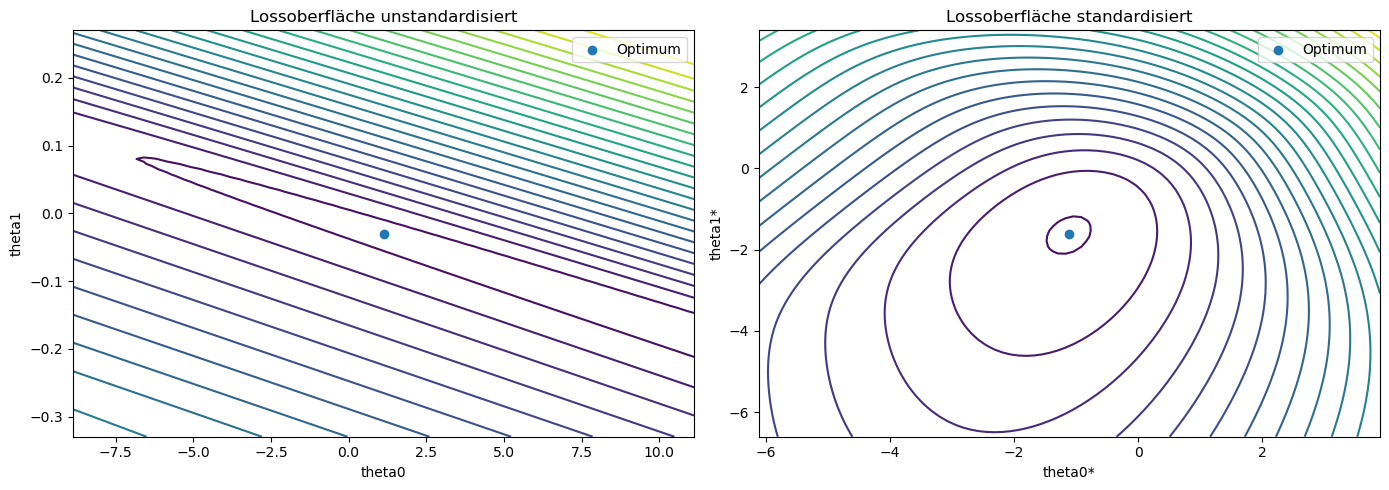

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].contour(T0, T1, Z_unstd, levels=30)
axes[0].scatter(theta0, theta1, label="Optimum")
axes[0].set_title("Lossoberfläche unstandardisiert")
axes[0].set_xlabel("theta0")
axes[0].set_ylabel("theta1")
axes[0].legend()

axes[1].contour(T0s, T1s, Z_std, levels=30)
axes[1].scatter(theta0_std, theta1_std, label="Optimum")
axes[1].set_title("Lossoberfläche standardisiert")
axes[1].set_xlabel("theta0*")
axes[1].set_ylabel("theta1*")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
#3D-Lossoberflächen

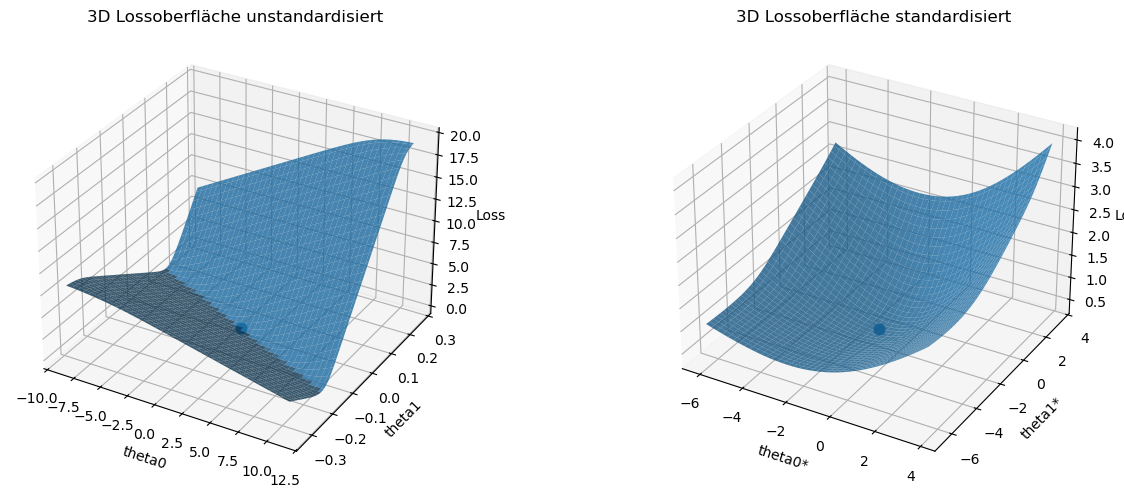

In [41]:
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(T0, T1, Z_unstd, alpha=0.8)
ax1.scatter(theta0, theta1, final_loss_unstd, s=60)
ax1.set_title("3D Lossoberfläche unstandardisiert")
ax1.set_xlabel("theta0")
ax1.set_ylabel("theta1")
ax1.set_zlabel("Loss")

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(T0s, T1s, Z_std, alpha=0.8)
ax2.scatter(theta0_std, theta1_std, final_loss_std, s=60)
ax2.set_title("3D Lossoberfläche standardisiert")
ax2.set_xlabel("theta0*")
ax2.set_ylabel("theta1*")
ax2.set_zlabel("Loss")

plt.tight_layout()
plt.show()

In [ ]:
#Erste 50 Schritte der Gradient-Descent-Trajektorie

In [42]:
path_unstd = gradient_descent_with_path(X_unstd, y, lr=0.001, max_iter=50)
path_std = gradient_descent_with_path(X_std, y, lr=0.1, max_iter=50)

In [ ]:
#Trajektorien auf den Lossoberflächen

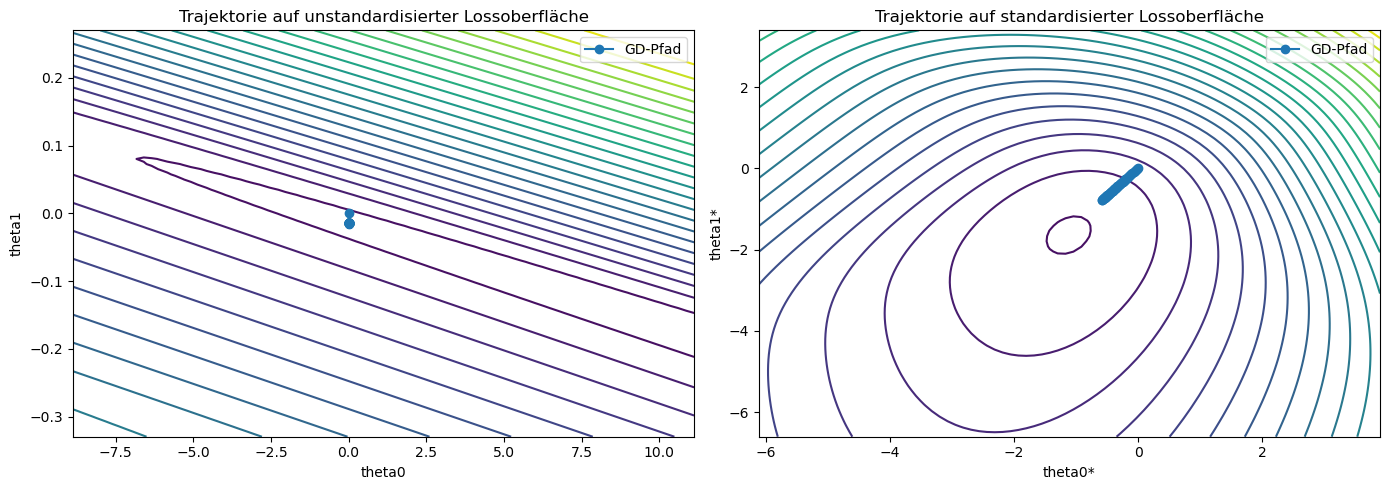

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].contour(T0, T1, Z_unstd, levels=30)
axes[0].plot(path_unstd[:, 0], path_unstd[:, 1], 'o-', label="GD-Pfad")
axes[0].set_title("Trajektorie auf unstandardisierter Lossoberfläche")
axes[0].set_xlabel("theta0")
axes[0].set_ylabel("theta1")
axes[0].legend()

axes[1].contour(T0s, T1s, Z_std, levels=30)
axes[1].plot(path_std[:, 0], path_std[:, 1], 'o-', label="GD-Pfad")
axes[1].set_title("Trajektorie auf standardisierter Lossoberfläche")
axes[1].set_xlabel("theta0*")
axes[1].set_ylabel("theta1*")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
#Grid Search über Lernrate und Iterationen

In [44]:
alphas = [0.001, 0.002, 0.005, 0.01, 0.02, 0.1, 1.0]
iterations_list = [100, 500, 1000, 5000, 10000]

results_std = np.zeros((len(alphas), len(iterations_list)))
results_unstd = np.zeros((len(alphas), len(iterations_list)))

for i, alpha in enumerate(alphas):
    for j, n_iter in enumerate(iterations_list):
        theta_tmp_std, _ = gradient_descent(X_std, y, lr=alpha, max_iter=n_iter, tol=0)
        results_std[i, j] = loss(theta_tmp_std, X_std, y)

        theta_tmp_unstd, _ = gradient_descent(X_unstd, y, lr=alpha, max_iter=n_iter, tol=0)
        results_unstd[i, j] = loss(theta_tmp_unstd, X_unstd, y)

In [ ]:
#Grid-Search-Ergebnisse visualisieren

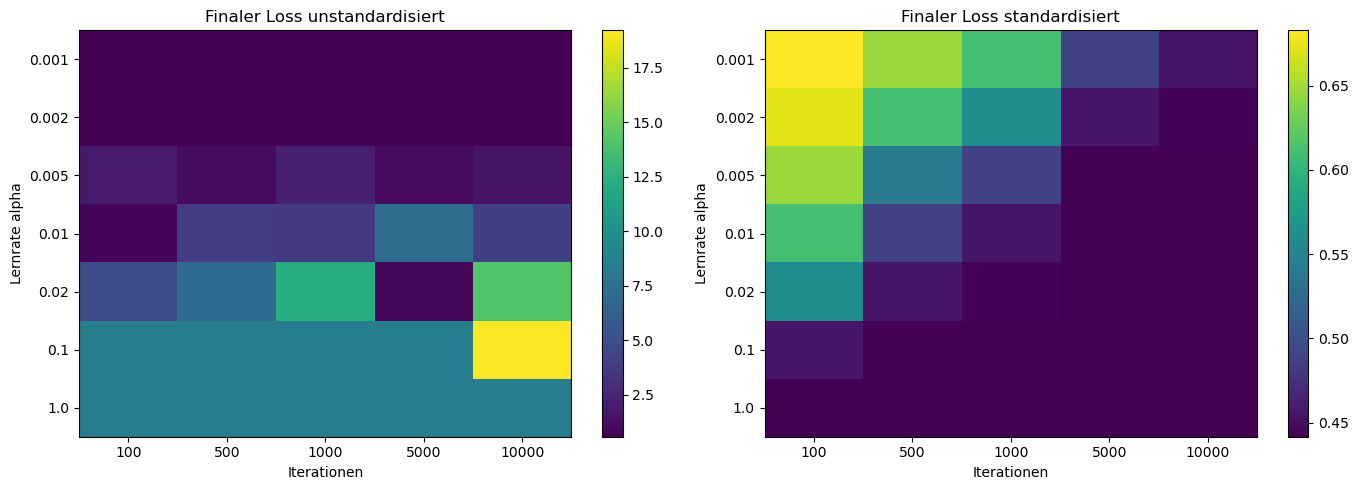

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(results_unstd, aspect='auto')
axes[0].set_xticks(range(len(iterations_list)))
axes[0].set_xticklabels(iterations_list)
axes[0].set_yticks(range(len(alphas)))
axes[0].set_yticklabels(alphas)
axes[0].set_xlabel("Iterationen")
axes[0].set_ylabel("Lernrate alpha")
axes[0].set_title("Finaler Loss unstandardisiert")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(results_std, aspect='auto')
axes[1].set_xticks(range(len(iterations_list)))
axes[1].set_xticklabels(iterations_list)
axes[1].set_yticks(range(len(alphas)))
axes[1].set_yticklabels(alphas)
axes[1].set_xlabel("Iterationen")
axes[1].set_ylabel("Lernrate alpha")
axes[1].set_title("Finaler Loss standardisiert")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

In [ ]:
#Beste Hyperparameter ausgeben

In [48]:
best_idx_unstd = np.unravel_index(np.argmin(results_unstd), results_unstd.shape)
best_idx_std = np.unravel_index(np.argmin(results_std), results_std.shape)

print("Beste Hyperparameter unstandardisiert:")
print("alpha =", alphas[best_idx_unstd[0]])
print("Iterationen =", iterations_list[best_idx_unstd[1]])
print("Loss =", results_unstd[best_idx_unstd])

print("\nBeste Hyperparameter standardisiert:")
print("alpha =", alphas[best_idx_std[0]])
print("Iterationen =", iterations_list[best_idx_std[1]])
print("Loss =", results_std[best_idx_std])

Beste Hyperparameter unstandardisiert:
alpha = 0.002
Iterationen = 10000
Loss = 0.5818778799247454

Beste Hyperparameter standardisiert:
alpha = 0.1
Iterationen = 5000
Loss = 0.44163462364727146
